In [31]:
import pandas as pd
from scipy.stats import ttest_1samp

In [32]:
df = pd.read_csv('../data/processed/rsa/judgment_distances/all_participants_judgments.csv')
df.head()

,Participant,V1,V4,V8,V9,Placed Confidence,Timed (days),Timed Confidence,X,Y,Z,True Time (days),Distance
0,P10,1.613036e+12,food_2_e1_11_nr_o_v1_old,"Checkpoint Pos : (-320.1, 88.3, 482.9)","Stimuli Pos : (-221.7, 88.3, 283.6)",23,14,37,-221.7,88.3,283.6,14,222.283100
1,P10,1.613037e+12,wealth_6_e2_15_r_o_v1_old,"Checkpoint Pos : (287.9, 63.4, 636.1)","Stimuli Pos : (-116.3, 63.4, 272.2)",4,1,46,-116.3,63.4,272.2,7,543.870500
2,P10,1.613037e+12,pirate_2_e3_11_nr_h_v1_old,"Checkpoint Pos : (-320.1, 88.3, 482.9)","Stimuli Pos : (-38.6, 88.3, 1182.9)",78,100,78,-38.6,88.3,1182.9,1,754.491100
3,P10,1.613037e+12,viking_8_e3_16_nr_h_v1_old,"Checkpoint Pos : (333.1, 53.3, 701.5)","Stimuli Pos : (-142.3, 53.3, 1275.2)",32,100,21,-142.3,53.3,1275.2,1,745.093800
4,P10,1.613037e+12,pirate_7_e3_1_nr_h_v1_old,"Checkpoint Pos : (-128.5, 90.6, 220.8)","Stimuli Pos : (-129.3, 90.6, 220.4)",78,14,82,-129.3,90.6,220.4,1,0.952219


# Spatial

## Confidence

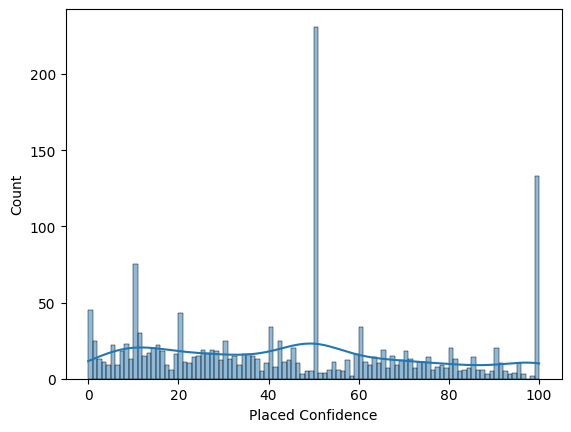

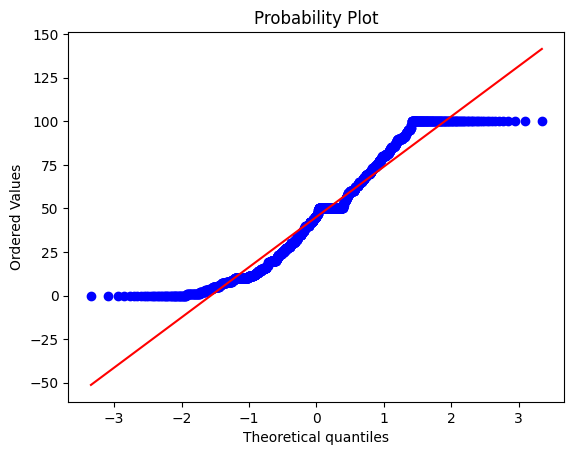

ShapiroResult(statistic=0.9480702916065816, pvalue=6.69803776828419e-24)

In [33]:

# test normal distribution
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.histplot(df['Placed Confidence'], bins=100, kde=True)
plt.show()
stats.probplot(df['Placed Confidence'], dist="norm", plot=plt)
plt.show()
stats.shapiro(df['Placed Confidence'])

Confidence threshold ≈ 0.00


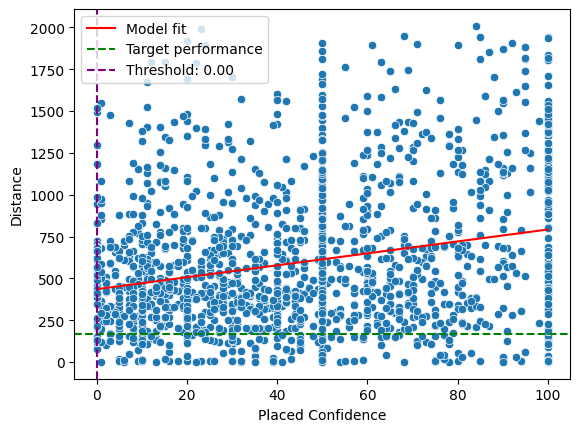

Correlation: 0.25, p-value: 0.0000


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Fit regression model
X = df['Placed Confidence'].values.reshape(-1, 1)
y = df['Distance'].values
reg = LinearRegression().fit(X, y)

# Predict distance across the confidence range
conf_range = np.linspace(df['Placed Confidence'].min(), df['Placed Confidence'].max(), 100).reshape(-1, 1)
pred_dist = reg.predict(conf_range)

# Choose a "good enough" performance threshold
# e.g., mean - 1 standard deviation (or an empirically defined acceptable distance)
acceptable_distance = y.mean() - y.std()

# Find the confidence level where predicted distance crosses that threshold
conf_threshold = conf_range[np.argmin(np.abs(pred_dist - acceptable_distance))][0]
print(f"Confidence threshold ≈ {conf_threshold:.2f}")

# Plot
sns.scatterplot(x='Placed Confidence', y='Distance', data=df)
plt.plot(conf_range, pred_dist, color='red', label='Model fit')
plt.axhline(acceptable_distance, color='green', linestyle='--', label='Target performance')
plt.axvline(conf_threshold, color='purple', linestyle='--', label=f'Threshold: {conf_threshold:.2f}')
plt.legend()
plt.show()

# print correlation and significance
spatial_corr, spatial_p_value = stats.pearsonr(df['Placed Confidence'], df['Distance'])
print(f"Correlation: {spatial_corr:.2f}, p-value: {spatial_p_value:.4f}")

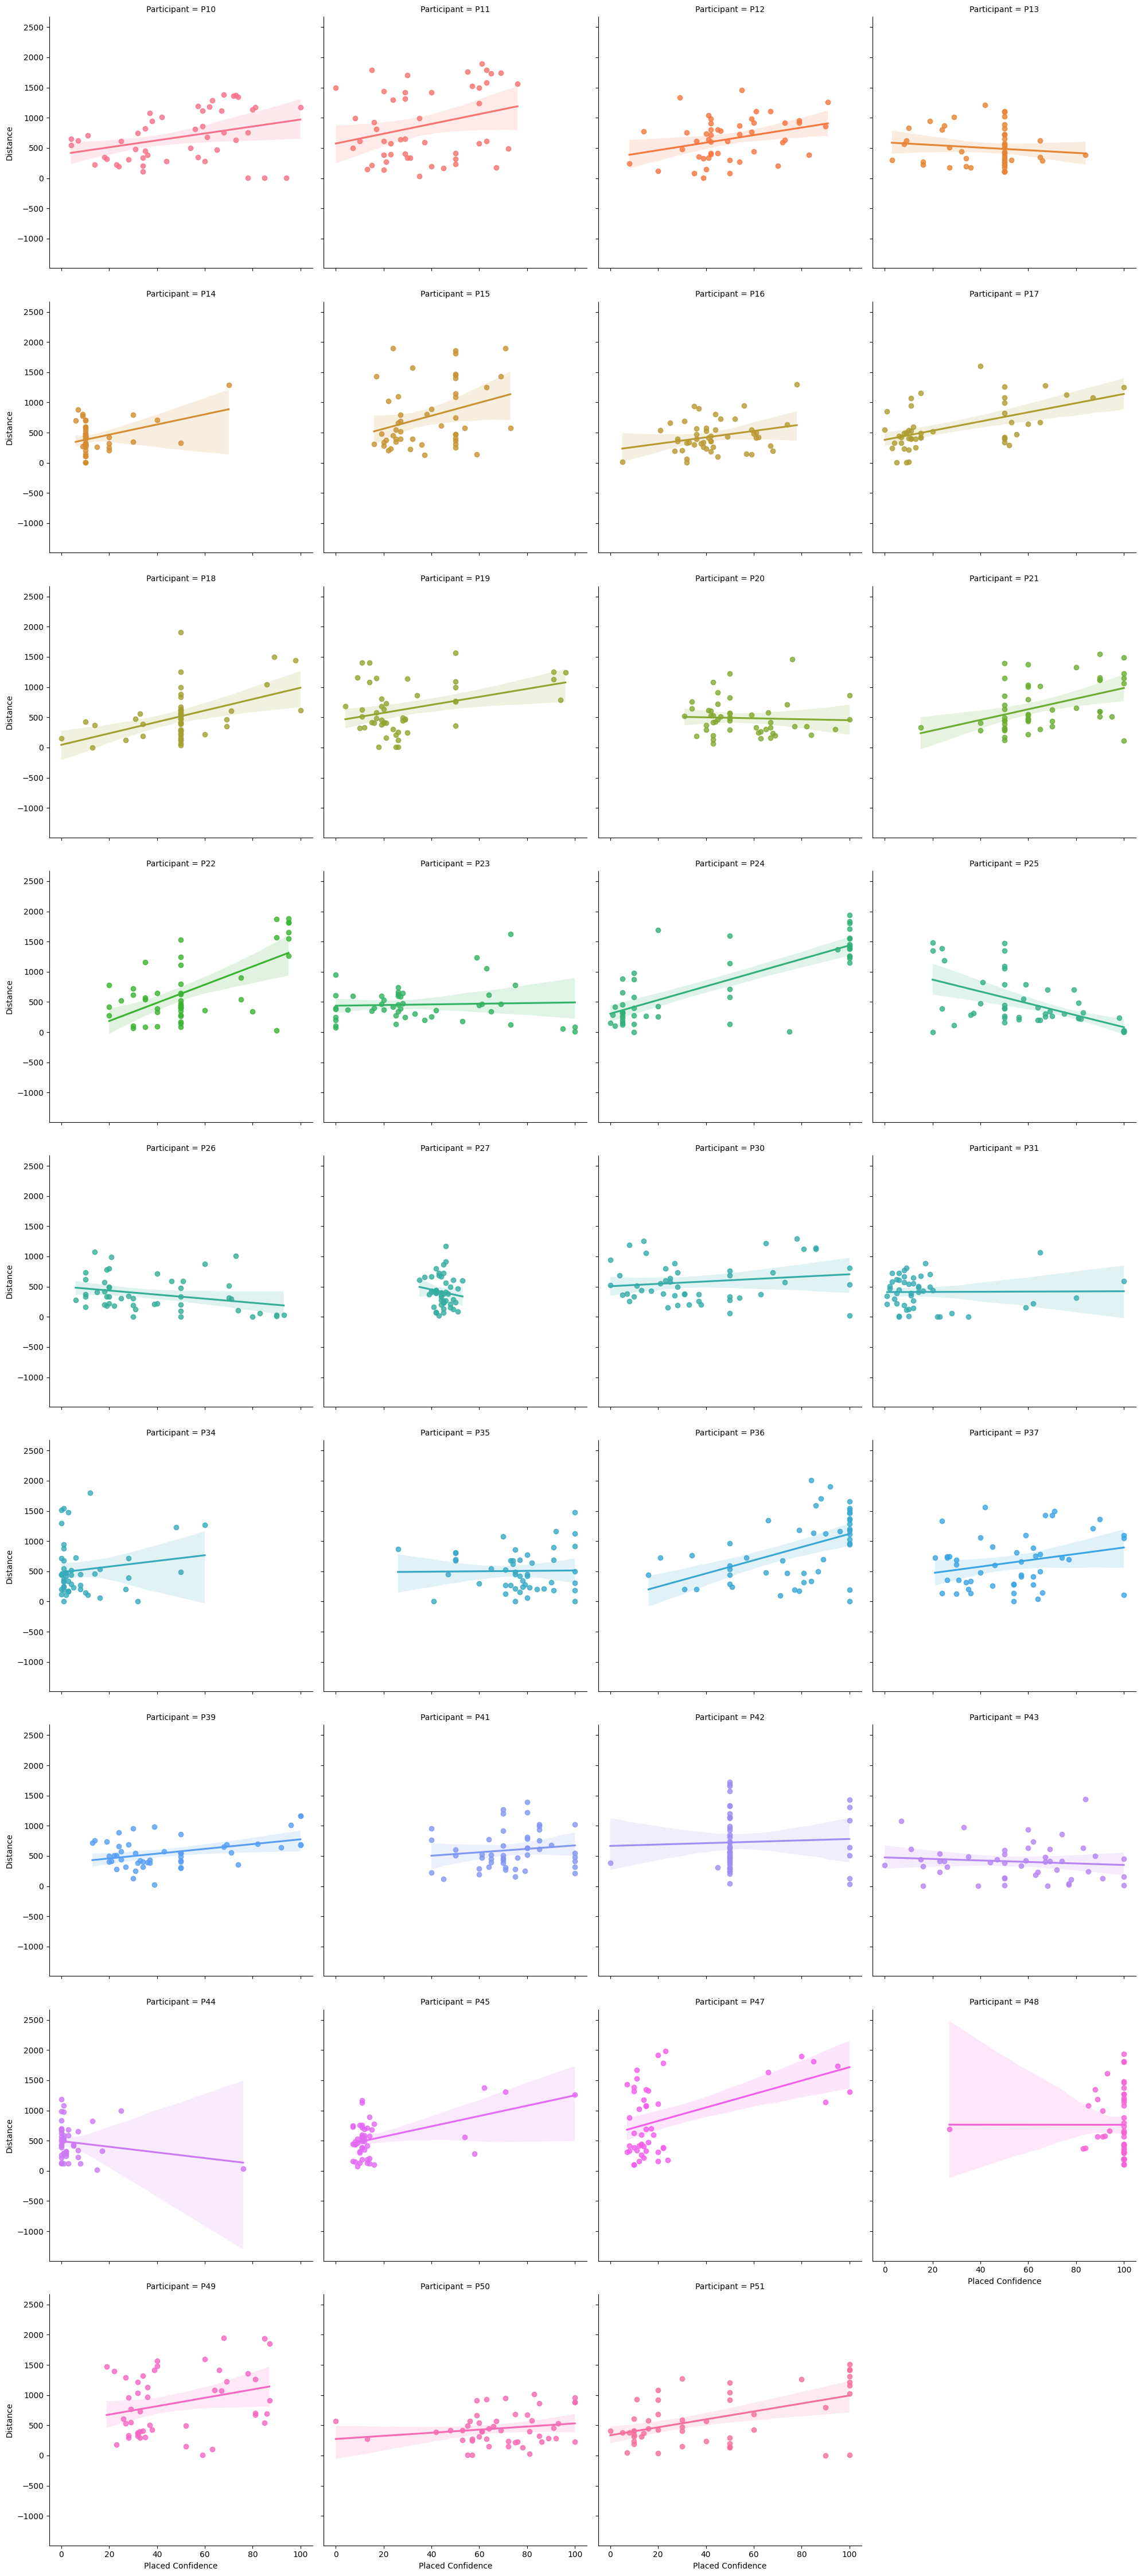

In [35]:
import seaborn as sns
sns.lmplot(x='Placed Confidence', y='Distance', data=df, hue='Participant', col='Participant', col_wrap=4)
plt.show()

In [36]:
# Compute within-subject correlations
per_participant_spatial_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Placed Confidence'].corr(x['Distance']))
)

# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_spatial_t, per_participant_spatial_p = ttest_1samp(per_participant_spatial_corrs, 0)
print(f"Mean r = {per_participant_spatial_corrs.mean():.3f}, t = {per_participant_spatial_t:.2f}, p = {per_participant_spatial_p:.4e}")

Mean r = 0.213, t = 4.39, p = 1.0319e-04


/tmp/ipykernel_3011296/1968254830.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


# Temporal

## Confidence

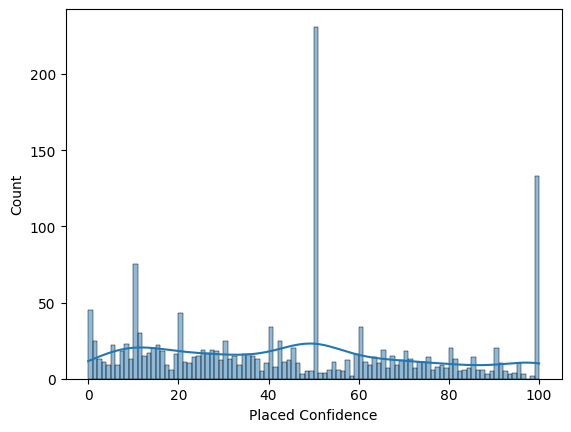

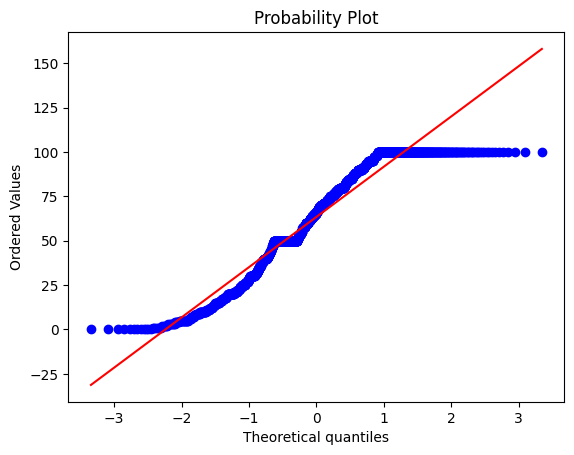

ShapiroResult(statistic=0.9287282496946011, pvalue=1.494626892800822e-27)

In [37]:
sns.histplot(df['Placed Confidence'], bins=100, kde=True)
plt.show()
# test normal distribution
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
stats.probplot(df['Timed Confidence'], dist="norm", plot=plt)
plt.show()
stats.shapiro(df['Timed Confidence'])

In [38]:
# Compute the difference (error)
df['Timed Error (days)'] = df['Timed (days)'] - df['True Time (days)']
df['Timed Correct'] = df['Timed (days)'] == df['True Time (days)']

### Overall

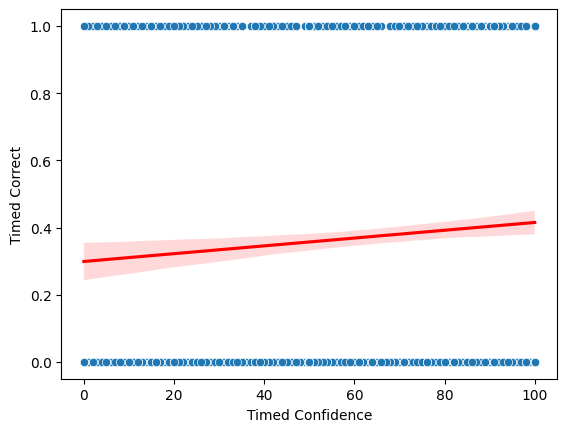

R2: 0.005
Pearsons correlation: 0.070, p-value: 0.0039


In [39]:
# plot
sns.scatterplot(x='Timed Confidence', y='Timed Correct', data=df)
# fit regression line
sns.regplot(x='Timed Confidence', y='Timed Correct', data=df, scatter=False, color='red')
# show r2
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Timed Confidence'].values.reshape(-1, 1)
y = df['Timed Correct'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
temporal_correct_corr, temporal_correct_p = pearsonr(df['Timed Confidence'], df['Timed Correct'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (temporal_correct_corr, temporal_correct_p))

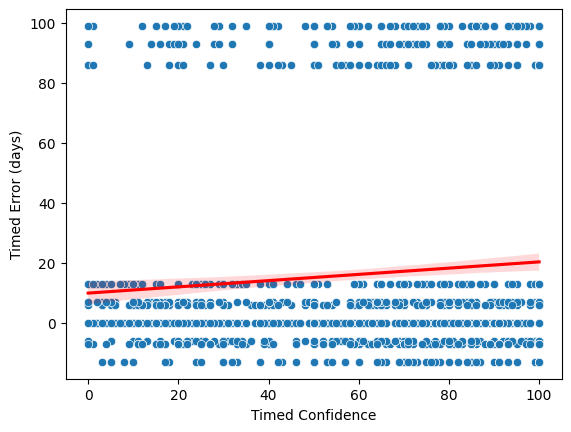

R2: 0.007
Pearsons correlation: 0.085, p-value: 0.0005


In [40]:
# plot
sns.scatterplot(x='Timed Confidence', y='Timed Error (days)', data=df)
# fit regression line
sns.regplot(x='Timed Confidence', y='Timed Error (days)', data=df, scatter=False, color='red')
# show r2
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Timed Confidence'].values.reshape(-1, 1)
y = df['Timed Error (days)'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
temporal_error_corr, temporal_error_p = pearsonr(df['Timed Confidence'], df['Timed Error (days)'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (temporal_error_corr, temporal_error_p))

### Per Patient

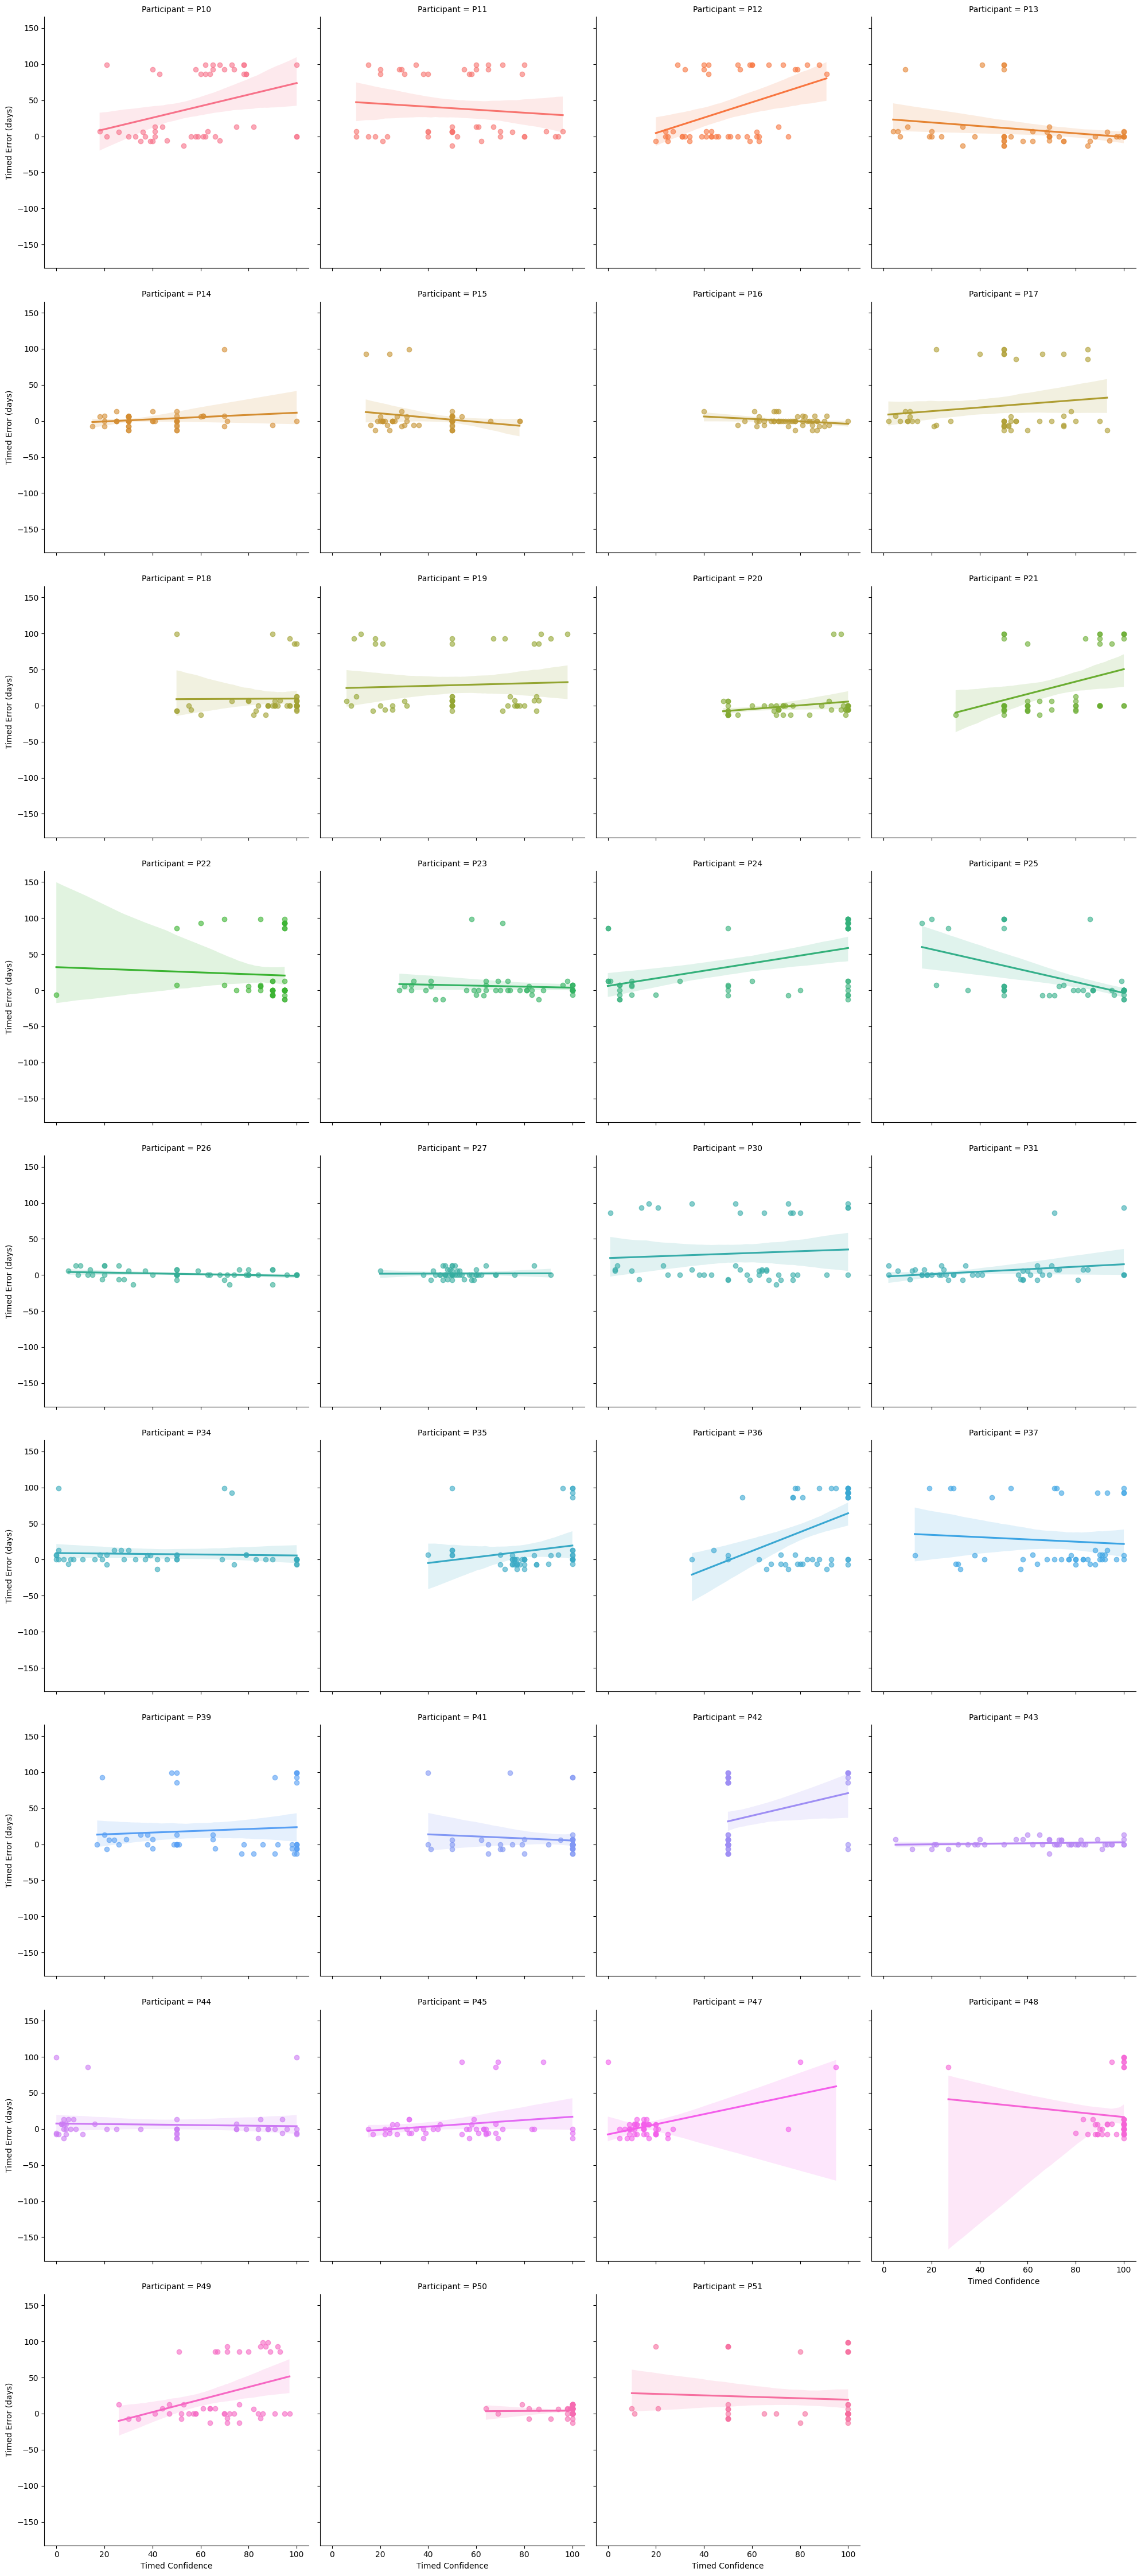

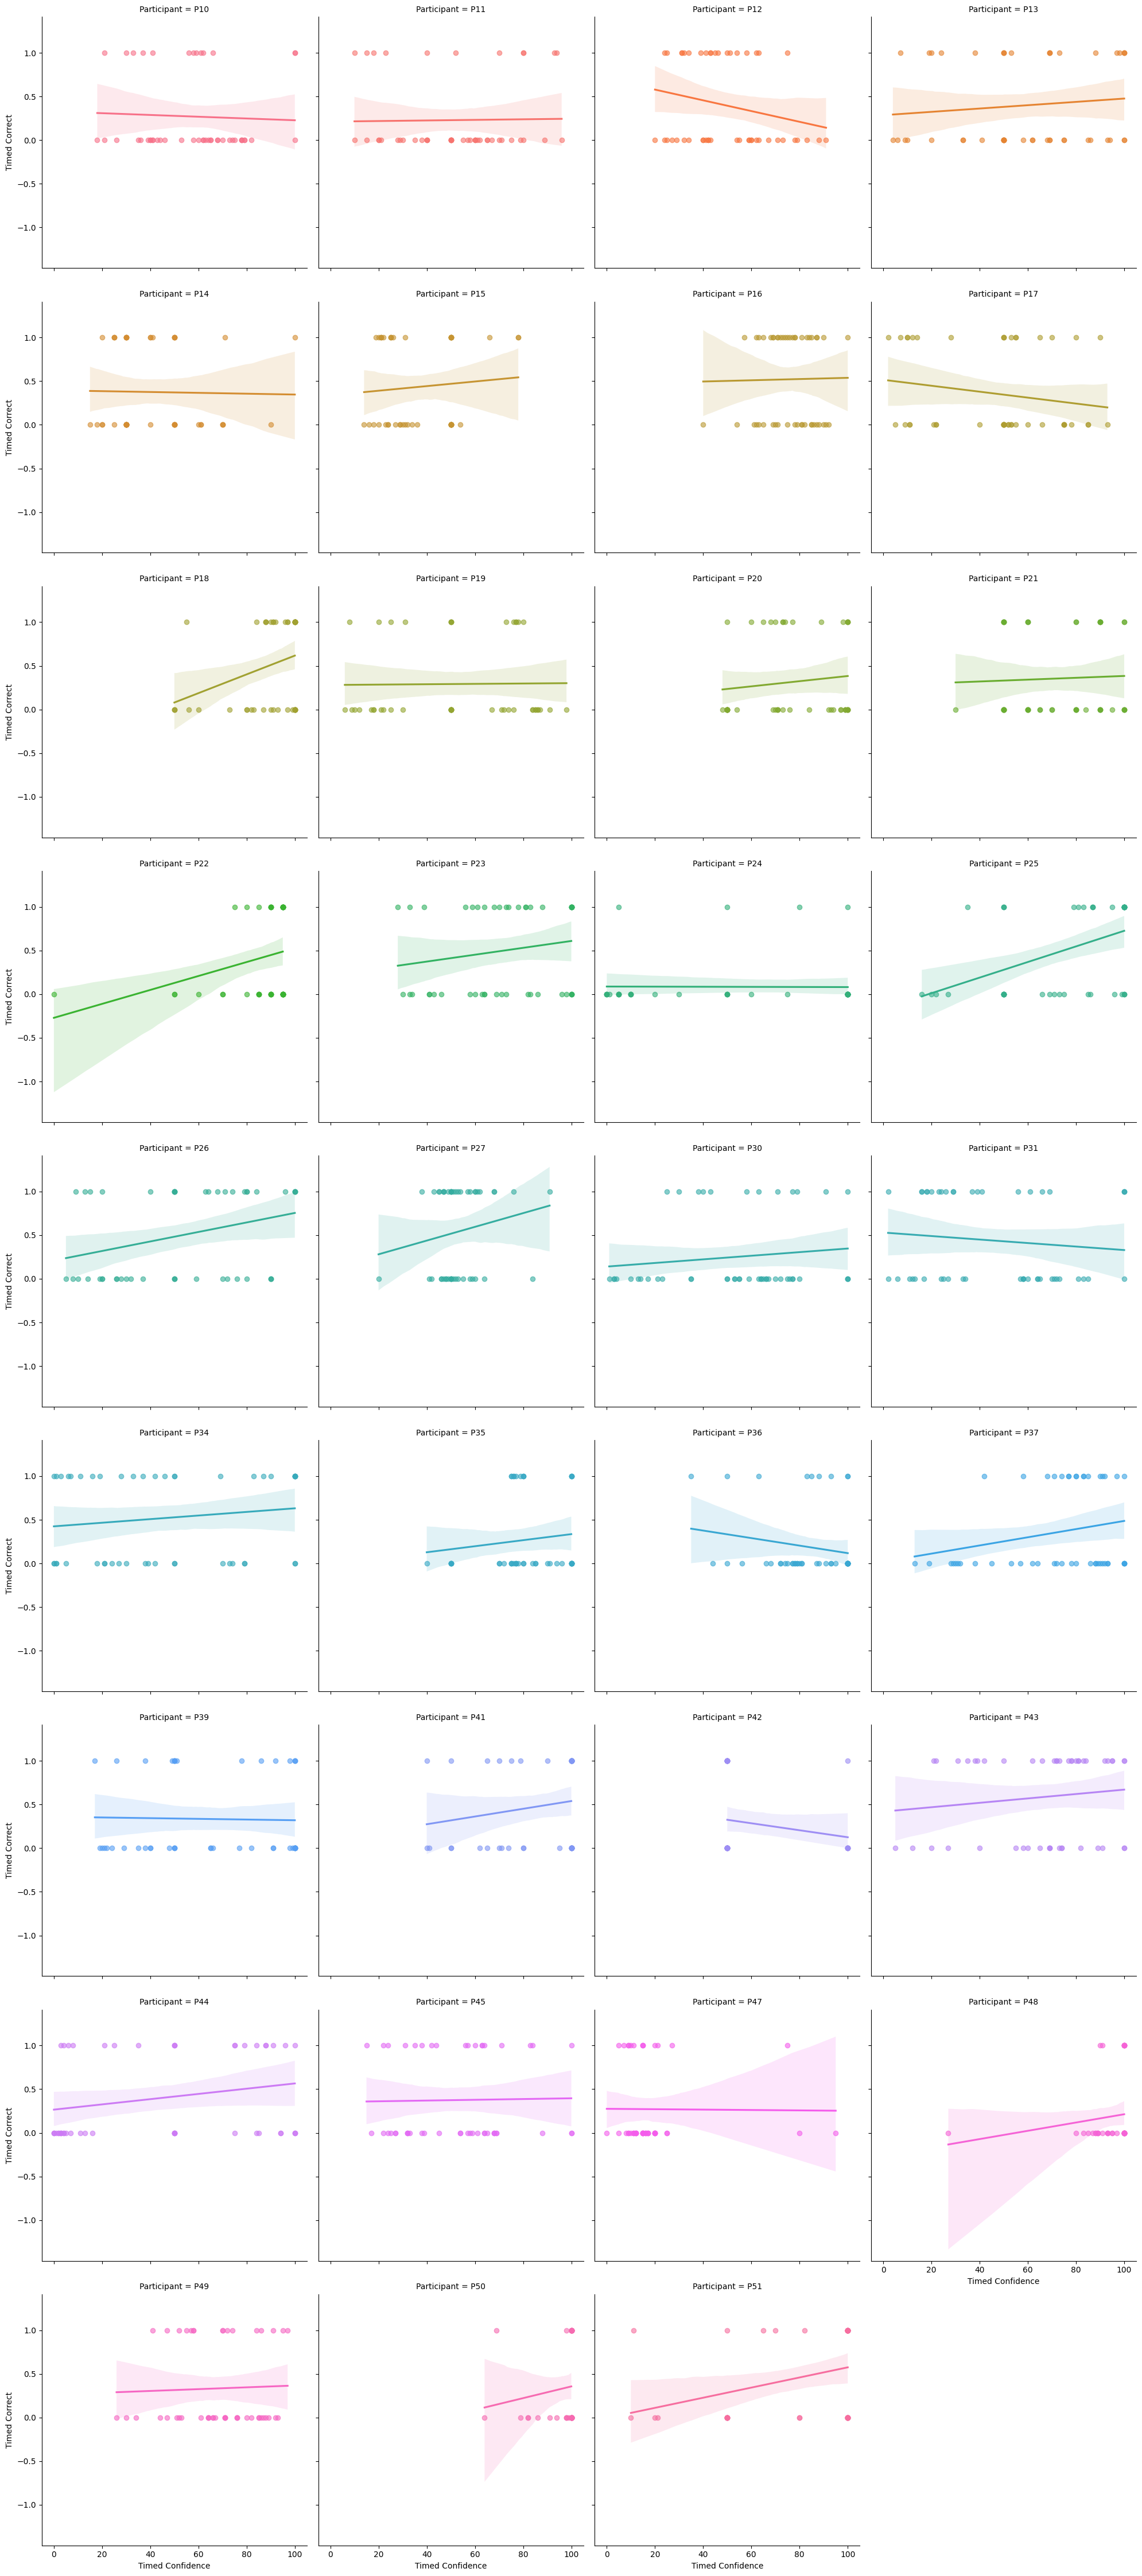

In [41]:

# Plot per participant
sns.lmplot(
    x='Timed Confidence',
    y='Timed Error (days)',
    data=df,
    hue='Participant',
    col='Participant',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)
plt.show()
# Plot per participant
sns.lmplot(
    x='Timed Confidence',
    y='Timed Correct',
    data=df,
    hue='Participant',
    col='Participant',
    col_wrap=4,
    scatter_kws={'alpha':0.6}
)
plt.show()

In [42]:
# Compute within-subject correlations
per_participant_temporal_correct_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Timed Confidence'].corr(x['Timed Correct']))
)

# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_temporal_t, per_participant_temporal_p = ttest_1samp(per_participant_temporal_correct_corrs, 0)
print(f"Mean r = {per_participant_temporal_correct_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")

Mean r = 0.085, t = 3.17, p = 3.2566e-03


/tmp/ipykernel_3011296/3429148399.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


In [43]:
# Compute within-subject correlations
per_participant_temporal_error_corrs = (
    df.groupby('Participant')
      .apply(lambda x: x['Timed Confidence'].corr(x['Timed Error (days)']))
)
# One-sample t-test: are mean correlations significantly > 0 ?
per_participant_temporal_t, per_participant_temporal_p = ttest_1samp(per_participant_temporal_error_corrs, 0)
print(f"Mean r = {per_participant_temporal_error_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")

Mean r = 0.079, t = 1.86, p = 7.1495e-02


/tmp/ipykernel_3011296/3506778965.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Participant')


# Correlation

## Confidence

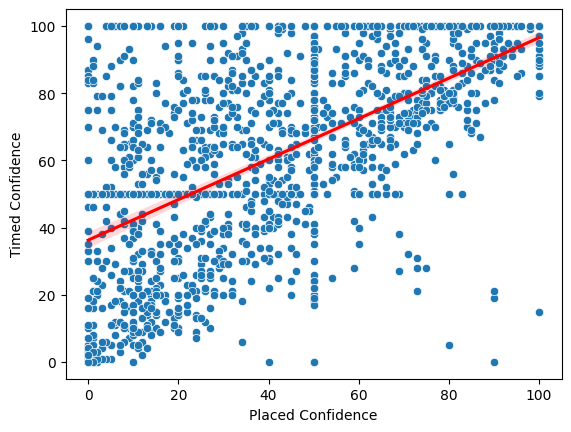

R2: 0.369
Pearsons correlation: 0.607, p-value: 0.0000


In [44]:
# study correlation between placed confidence and timed confidence
# plot
sns.scatterplot(x='Placed Confidence', y='Timed Confidence', data=df)
# fit regression line
sns.regplot(x='Placed Confidence', y='Timed Confidence', data=df, scatter=False, color='red')
# show r2   
plt.show()
# calculate r2
from sklearn.linear_model import LinearRegression
X = df['Placed Confidence'].values.reshape(-1, 1)
y = df['Timed Confidence'].values
reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print('R2: %.3f' % r2)
# Pearson correlation
from scipy.stats import pearsonr
inter_corr, inter_p = pearsonr(df['Placed Confidence'], df['Timed Confidence'])
print('Pearsons correlation: %.3f, p-value: %.4f' % (inter_corr, inter_p))

## Two variable Normal Distribution ? 

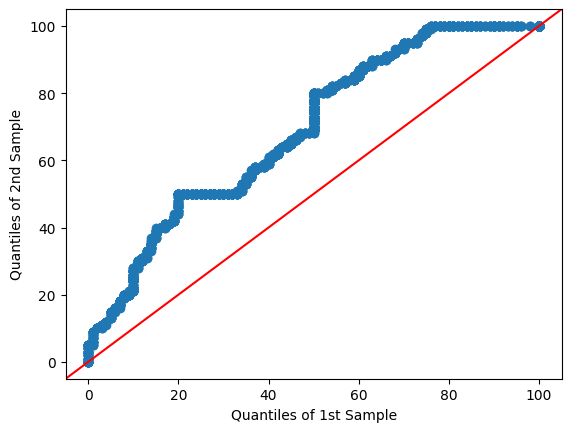

In [45]:
# study if two variables are normally distributed

sm.qqplot_2samples(df['Placed Confidence'], df['Timed Confidence'], line='45')
plt.show()

# Conclusions

In [46]:
# Print conclusions of all findings
print("Findings Summary:")
print("--- Overall ---")
print(f"Spatial Judgment - Correlation between Placed Confidence and Distance: r = {spatial_corr:.2f}, p = {spatial_p_value:.4f}")
print(f"Temporal Judgment - Correlation between Timed Confidence and Timed Correct: r = {temporal_correct_corr:.2f}, p = {temporal_correct_p:.4f}")
print(f"Temporal Judgment - Correlation between Timed Confidence and Timed Error (days): r = {temporal_error_corr:.2f}, p = {temporal_error_p:.4f}")
print(f"Inter-Domain - Correlation between Placed Confidence and Timed Confidence: r = {inter_corr:.2f}, p = {inter_p:.4f}")    

print("--- Per Participant ---")
print(f"Spatial Judgment - Mean within-participant correlation: r = {per_participant_spatial_corrs.mean():.3f}, t = {per_participant_spatial_t:.2f}, p = {per_participant_spatial_p:.4e}")
print(f"Temporal Judgment (Correct) - Mean within-participant correlation: r = {per_participant_temporal_correct_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")
print(f"Temporal Judgment (Error) - Mean within-participant correlation: r = {per_participant_temporal_error_corrs.mean():.3f}, t = {per_participant_temporal_t:.2f}, p = {per_participant_temporal_p:.4e}")    


Findings Summary:
--- Overall ---
Spatial Judgment - Correlation between Placed Confidence and Distance: r = 0.25, p = 0.0000
Temporal Judgment - Correlation between Timed Confidence and Timed Correct: r = 0.07, p = 0.0039
Temporal Judgment - Correlation between Timed Confidence and Timed Error (days): r = 0.09, p = 0.0005
Inter-Domain - Correlation between Placed Confidence and Timed Confidence: r = 0.61, p = 0.0000
--- Per Participant ---
Spatial Judgment - Mean within-participant correlation: r = 0.213, t = 4.39, p = 1.0319e-04
Temporal Judgment (Correct) - Mean within-participant correlation: r = 0.085, t = 1.86, p = 7.1495e-02
Temporal Judgment (Error) - Mean within-participant correlation: r = 0.079, t = 1.86, p = 7.1495e-02
